# ICE and PG performance measure

## Dependencies

In [1]:
from ONNX_Predict.LSTM_onnx import LSTM_onnx 
from ONNX_Predict.Scaler_onnx import Scaler_onnx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import tensorflow as tf

2026-01-26 16:34:29.933941: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-26 16:34:29.952062: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-26 16:34:29.952076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-26 16:34:29.952726: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-26 16:34:29.956474: I tensorflow/core/platform/cpu_feature_guar

As observed, it is not necessary to import `tensorflow` or `keras` unless required in some additional part of the process.

`ONNX_Predict` is responsible for managing the memory loading process and prediction interface of the models and scalers

**Update:** `tensorflow` is imported here to conduct a comparison experiment between the original models and their ONNX counterparts.

## Reading models and scalers

### Paths

The paths where the `onnx` models are stored are defined, as well as the original `ICE` and `PG` models

In [2]:
ICE_folder = os.path.join('CTTC_models', 'ONNX', 'ICE')
PG_folder = os.path.join('CTTC_models', 'ONNX', 'PG')
tf_model = 'model.h5'

### Loading ICE model in memory

To load the models into memory, an instance of the `Scaler_onnx` class must be created for the scalers and `LSTM_onnx` for the models*

In [3]:
ICEscaler_in = Scaler_onnx('scaler_input.onnx', ICE_folder)
ICEscaler_out = Scaler_onnx('scaler_output.onnx', ICE_folder)
ICEscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', ICE_folder)
ICE = LSTM_onnx('ICE_onnx.onnx', ICE_folder, tf_model)

2026-01-26 16:34:33.032776269 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2292970, index: 10, mask: {11, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-01-26 16:34:33.032788752 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2292966, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-01-26 16:34:33.032762163 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2292962, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-01-26 16:34:33.033329485 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2292965, index: 5, mask: {6, }, error code: 22 error msg: Invalid argument. Specify the

**IMPORTANT**

Note that 3 scalers are loaded into memory instead of 2.

This is because onnx models can only perform the transformation in one direction. Requiring an inverse transformation for prediction, `scaler_inverse_output.onnx` had to be generated for each model

### Loading PG model in memory

In [4]:
PGscaler_in = Scaler_onnx('scaler_input.onnx', PG_folder)
PGscaler_out = Scaler_onnx('scaler_output.onnx', PG_folder)
PGscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', PG_folder)
PG = LSTM_onnx('PG_onnx.onnx', PG_folder, tf_model)

2026-01-26 16:34:33.876567530 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2293015, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-01-26 16:34:33.885327038 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2293017, index: 4, mask: {5, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-01-26 16:34:33.885896154 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2293016, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-01-26 16:34:33.886352420 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 2293018, index: 5, mask: {6, }, error code: 22 error msg: Invalid argument. Specify the n

Same as `ICE`

## Reading input vectors

### Path and config vars

The csv file `part_000100.csv` is selected

In turn, the column names were taken from the model training data

In [5]:
csvPath = "part_000100.csv"
input_cols = [
    "ICE_Speed_rpm",
    "fuel_mg",
    "T_amb_K",
    "p_amb_bar",
    "ICE_Speed_soll_rpm",
    "EM2_Torque_Nm",
    "ICE_Torque_Nm",
    "Brake_perc",
]

#### Loading dataframe in memory

In [6]:
df = pd.read_csv(csvPath, names=input_cols, skiprows=1)
ICEinput = df.iloc[:,:4].copy()
PGinput = df.iloc[:,4:].copy()

#Adjusting speed value
PGinput.loc[PGinput['ICE_Speed_soll_rpm'] < 900] = 0

## Preprocess

### Model Reset

In [7]:
ICE.reset_states()

### Input vector

The first row of the selected file will be used

In [8]:
x = ICEinput.iloc[:1].copy()
x = x.to_numpy()
x = x.astype('float32')

#### Scaling the input vector

In [9]:
x_scaled = ICEscaler_in.transform(x)
x_scaled = np.reshape(x_scaled, (1,1,4))

**IMPORTANT:**

We work directly with `numpy` for casting and/or reshaping vectors, instead of using `tensorflow`

### Preparing initial auxiliar data

The default data defined in the `transition_function_model` class defined in the script with the same name is taken as an example:

- Torque  --> 0 
- NO_ini  --> 0
- NO2_ini --> 0
- CO_ini  --> 0
- CO2_ini --> 0

In [10]:
Torque = 0
NO_ini = 0
NO2_ini = 0
CO_ini = 0
CO2_ini = 0
y_ini = np.array([[Torque, NO_ini, NO2_ini, CO_ini, CO2_ini]], dtype='float32')
y_scaled_ini = ICEscaler_out.transform(y_ini)[0].reshape((1,1,5))

## Prediction

### ICE model prediction behaviour

In [11]:
y_predict_scaled_list = []

#### - 1st prediction call

In [12]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.79309154, -0.99261713, -0.9964769 , -0.99629915,
          -0.9952043 ]]], dtype=float32)]

#### - 2nd prediction call

In [13]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.36389303, -0.99757624, -1.0069705 , -1.0029442 ,
          -0.99704516]]], dtype=float32)]

#### - 3rd prediction call

In [14]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14948566, -0.9296564 , -0.9802153 , -0.94951165,
          -0.9990152 ]]], dtype=float32)]

#### - 4th prediction call

In [15]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14641733, -0.6010861 , -0.9596789 , -0.9276561 ,
          -0.99618065]]], dtype=float32)]

#### - 5th prediction call

In [16]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14785172, -0.51661503, -0.99532473, -0.94011337,
          -0.99781585]]], dtype=float32)]

### Plot of scaled results

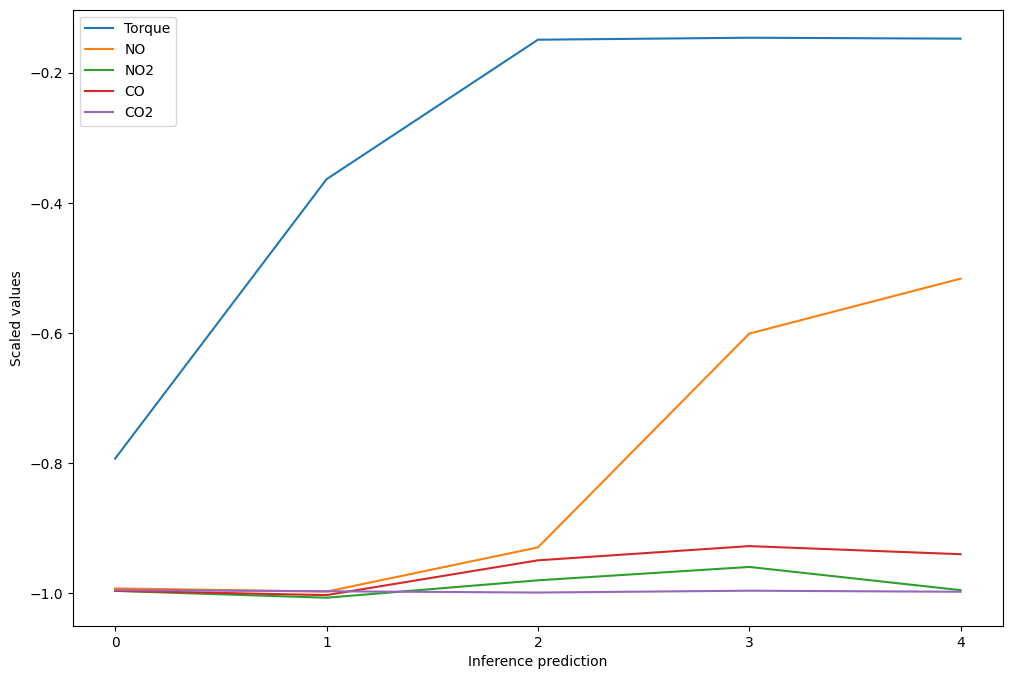

In [17]:
plot_data = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data.shape

labels = ['Torque', 'NO', 'NO2', 'CO', 'CO2']

_, ax = plt.subplots(figsize=(12,8))
for var in range(plot_vars):
    ax.plot(plot_data[:,var], label=labels[var])

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Scaled values')
ax.set_xlabel('Inference prediction')
ax.legend()

plt.show()

## ICE preformance time

In [18]:
%%timeit
ICE([x_scaled, y_scaled_ini])

30.7 μs ± 84.9 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Post-process

In [19]:
y_pred_list = []

for pred in range(preds):
    y_pred = ICEscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])

plot_data = np.array(y_pred_list)

### See results

In [20]:
y_pred = pd.DataFrame(data=plot_data, columns=labels)
y_pred

,Torque,NO,NO2,CO,CO2
0,-30.663244,0.001071,0.000008,0.000536,0.002289
1,91.710686,0.000352,-0.000015,-0.000426,0.001410
2,152.842941,0.010206,0.000043,0.007306,0.000470
3,153.717789,0.057880,0.000087,0.010468,0.001823
4,153.308807,0.070137,0.000010,0.008666,0.001042


#### Basic statistics

In [21]:
y_pred.describe().loc[['mean', 'std']]

,Torque,NO,NO2,CO,CO2
mean,104.183395,0.027929,0.000026,0.005310,0.001407
std,79.959206,0.033446,0.000040,0.004938,0.000700


**IMPORTANT:**

It can be observed how the first torque prediction produces a negative result --> `-30.66 Nm`

### Plot results

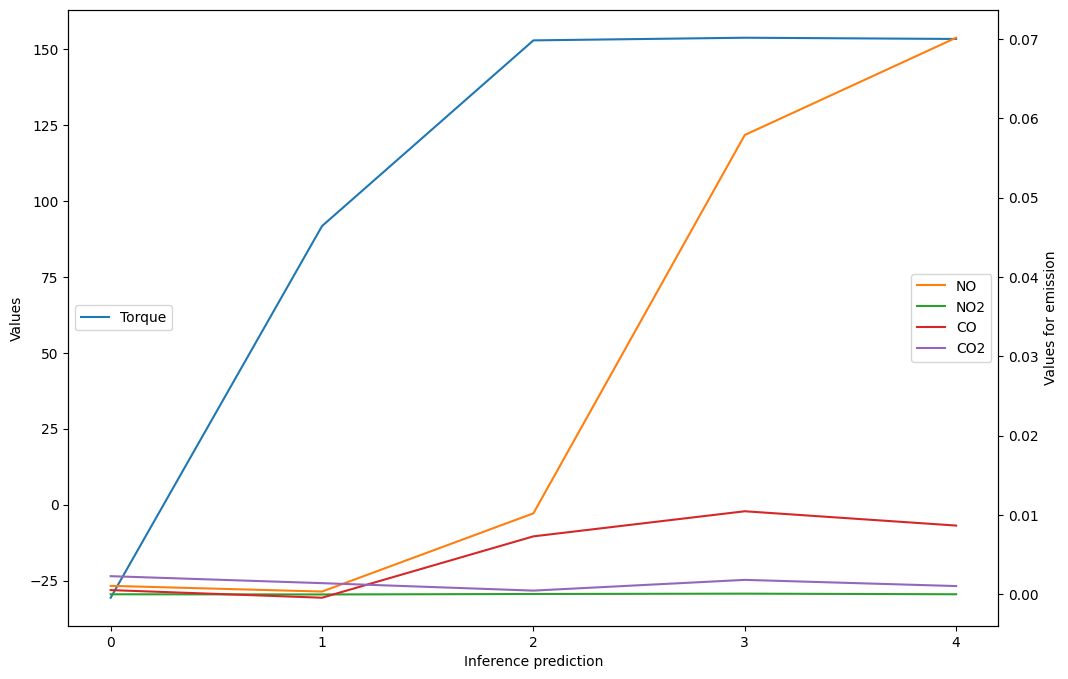

In [22]:
_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for emission')
ax2.legend(loc='center right')

plt.show()

## TensorFlow ICE Experiment
We will now run the identical experiment using the original TensorFlow/Keras model to evaluate consistency and performance differences.

In [23]:
ICE_tf_path = os.path.join(ICE_folder, tf_model)
print(f"Loading TF bucket from: {ICE_tf_path}")
ICE_tf = tf.keras.models.load_model(ICE_tf_path)

Loading TF bucket from: CTTC_models/ONNX/ICE/model.h5


### Consistency Check (ICE)

In [24]:
%%timeit
ICE_tf([x_scaled, y_scaled_ini])

14.2 ms ± 17.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### TensorFlow ICE preformance time

In [25]:
ICE_tf.reset_states()

y_predict_scaled_tf_list = []

# Identical sequence of 5 calls
for _ in range(5):
    # TF model returns a tensor, we convert to numpy
    # Input shapes: x_scaled (1,1,4), y_scaled_ini (1,1,5)
    # TF Model expects list [input_1, input_2]
    pred = ICE_tf([x_scaled, y_scaled_ini])
    y_predict_scaled_tf_list.append(pred.numpy()[0][0])
    
y_predict_scaled_tf = np.array(y_predict_scaled_tf_list)
y_predict_scaled_tf

array([[-0.7930916 , -0.9926171 , -0.9964769 , -0.99629915, -0.9952042 ],
       [-0.3638931 , -0.99757624, -1.0069705 , -1.0029442 , -0.99704516],
       [-0.14948565, -0.9296563 , -0.9802152 , -0.9495117 , -0.9990152 ],
       [-0.14641732, -0.601086  , -0.95967877, -0.92765605, -0.9961809 ],
       [-0.14785163, -0.51661503, -0.99532473, -0.94011337, -0.9978157 ]],
      dtype=float32)

Overall Max Absolute Difference: 2.384185791015625e-07
Overall Mean Absolute Difference (MAE): 5.0067900048134106e-08
Overall Root Mean Squared Error (RMSE): 7.667946988476615e-08
------------------------------
Per-variable metrics:
  Variable  Max Difference           MAE          RMSE
0   Torque    8.940697e-08  4.768372e-08  5.575504e-08
1       NO    5.960464e-08  3.576279e-08  4.616956e-08
2      NO2    1.192093e-07  4.768372e-08  7.539457e-08
3       CO    5.960464e-08  2.384186e-08  3.769729e-08
4      CO2    2.384186e-07  9.536743e-08  1.305872e-07


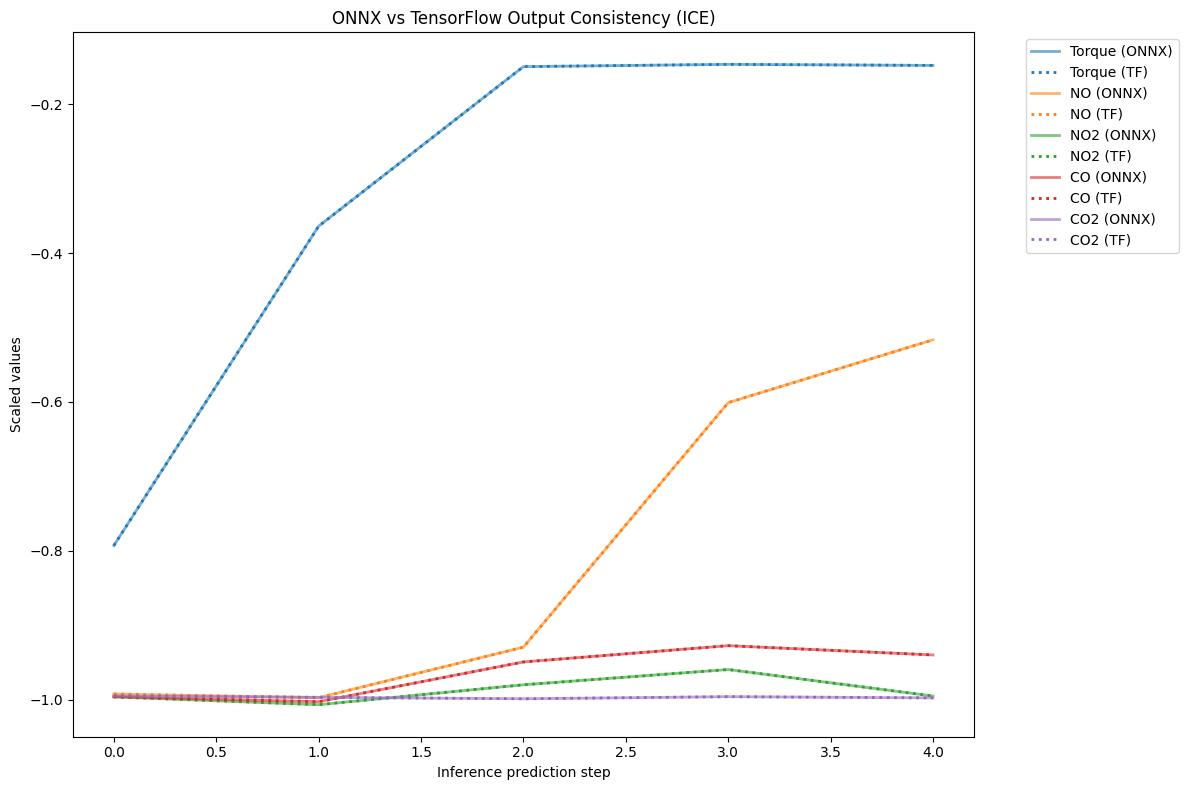

In [26]:
# Create DataFrame for comparison
onnx_results = np.array(y_predict_scaled_list) # From previous ONNX run
tf_results = np.array(y_predict_scaled_tf_list)

diff = np.abs(onnx_results - tf_results)

# Calculate metrics
max_diff = np.max(diff, axis=0) # Max difference per variable
avg_diff = np.mean(diff, axis=0) # MAE per variable
rmse = np.sqrt(np.mean((onnx_results - tf_results)**2, axis=0)) # RMSE per variable

overall_max = np.max(diff)
overall_mae = np.mean(diff)
overall_rmse = np.sqrt(np.mean((onnx_results - tf_results)**2))

print(f"Overall Max Absolute Difference: {overall_max}")
print(f"Overall Mean Absolute Difference (MAE): {overall_mae}")
print(f"Overall Root Mean Squared Error (RMSE): {overall_rmse}")
print("-" * 30)

# Create a summary dataframe for per-variable metrics
metrics_df = pd.DataFrame({
    'Variable': labels,
    'Max Difference': max_diff,
    'MAE': avg_diff,
    'RMSE': rmse
})
print("Per-variable metrics:")
print(metrics_df)

# Plotting Comparison
_, ax = plt.subplots(figsize=(12,8))

for var in range(plot_vars):
    color = f'C{var}'
    ax.plot(onnx_results[:, var], label=f'{labels[var]} (ONNX)', linestyle='-', color=color, alpha=0.6, linewidth=2)
    ax.plot(tf_results[:, var], label=f'{labels[var]} (TF)', linestyle=':', color=color, alpha=1.0, linewidth=2)

ax.set_ylabel('Scaled values')
ax.set_xlabel('Inference prediction step')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('ONNX vs TensorFlow Output Consistency (ICE)')
plt.tight_layout()
plt.show()

## Repeat process for PG

### Model reset

In [27]:
PG.reset_states()

### Prepare input vector

As with the ICE model, the first row of the selected file is selected

In [28]:
x = PGinput.iloc[:1].copy()

#### Removing NaN value

In [29]:
x.iloc[:,2] = y_pred['Torque'].iloc[-1]
x = x.to_numpy()
x = x.astype('float32')

#### Scalling the input vector 

In [30]:
x_scaled = PGscaler_in.transform(x)
x_scaled = np.reshape(x_scaled, (1,1,4))

#### Preparing initial auxiliar vector

Again, the default values defined in the `main.ipynb` and `transition_function_model.py` files are taken

In [31]:
SOC_ini = 0.7
velocity_ini = 0

y_ini = np.array([[velocity_ini, SOC_ini]], dtype='float32')
y_scaled_ini = PGscaler_out.transform(y_ini)[0].reshape((1,1,2))

### PG model prediction behaviour

A similar behavior to the ICE model has been evidenced but with much smaller variations than those observed for ICE

In [32]:
y_predict_scaled_list = []

#### - 1st prediction call

In [33]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19865346,  0.4024752 ]]], dtype=float32)]

#### - 2nd prediction call

In [34]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.20063496,  0.40876147]]], dtype=float32)]

#### - 3rd prediction call

In [35]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.18923528,  0.4033029 ]]], dtype=float32)]

#### - 4th prediction call

In [36]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19683796,  0.40699986]]], dtype=float32)]

#### - 5th prediction call

In [37]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19293256,  0.4072388 ]]], dtype=float32)]

Please note how the values of the input vector set **are NOT modified** between calls. That is, for the same set of input vectors, different prediction values are obtained.

### Plotting scaled results

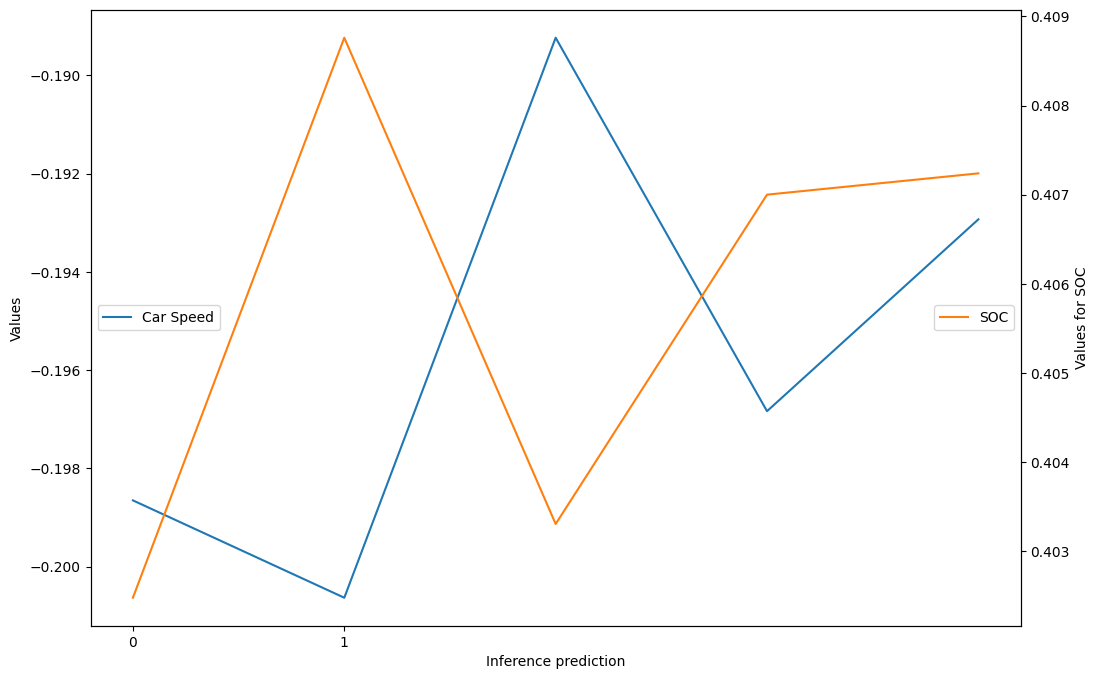

In [38]:
plot_data = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data.shape

labels = ['Car Speed', 'SOC']

_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for SOC')
ax2.legend(loc='center right')

plt.show()

## PG preformance time

In [39]:
%%timeit
PG([x_scaled, y_scaled_ini])

87.3 μs ± 11.1 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Post-process

In [40]:
y_pred_list = []

for pred in range(preds):
    y_pred = PGscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])

plot_data = np.array(y_pred_list)

### See results

In [41]:
y_pred = pd.DataFrame(data=plot_data, columns=labels)
y_pred

,Car Speed,SOC
0,0.934679,0.701024
1,0.605807,0.704167
2,2.497827,0.701438
3,1.236000,0.703286
4,1.884184,0.703405


#### Basic statistics

In [42]:
y_pred.describe().loc[['mean', 'std']]

,Car Speed,SOC
mean,1.431699,0.702664
std,0.759736,0.001359


**Important:**

Observe the high standard deviation value of the predicted speed for the same pair of input vectors

### Plot results

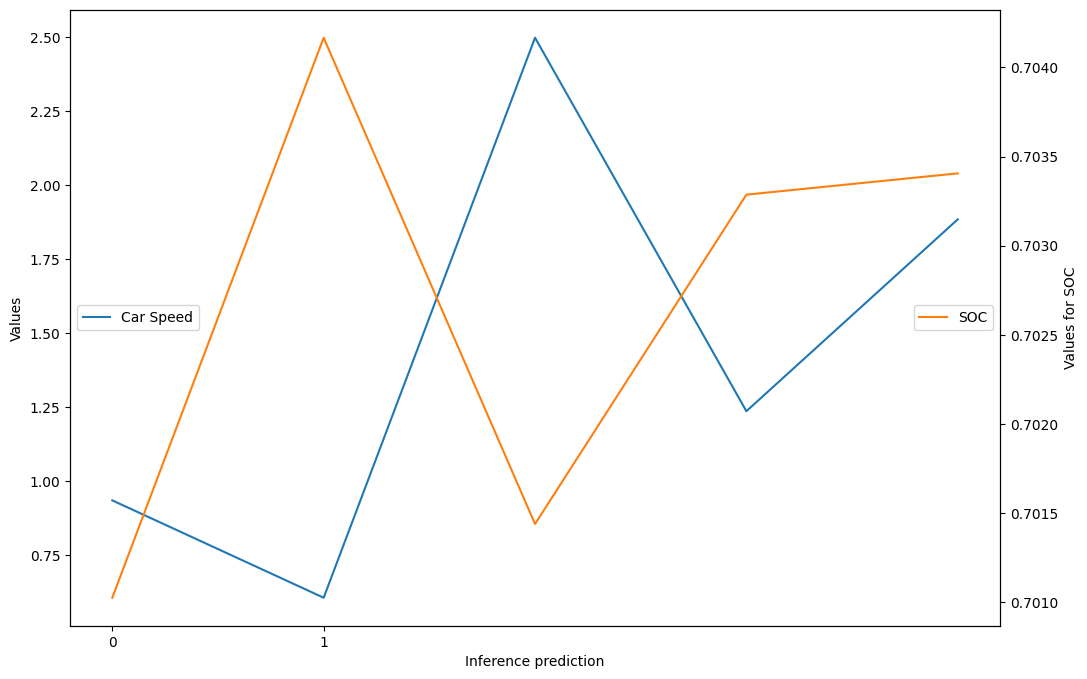

In [43]:
_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for SOC')
ax2.legend(loc='center right')

plt.show()

## TensorFlow PG Experiment
We repeat the consistency and performance check for the PG model.

In [44]:
PG_tf_path = os.path.join(PG_folder, tf_model)
PG_tf = tf.keras.models.load_model(PG_tf_path)

### Consistency Check (PG) - Real Units (Inverse Scaled)

In [45]:
%%timeit
PG_tf([x_scaled, y_scaled_ini])

14.6 ms ± 18.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Consistency Check (PG)

In [46]:
PG_tf.reset_states()
y_predict_scaled_pg_tf_list = []

for _ in range(5):
    # Using current x_scaled and y_scaled_ini from PG section
    pred = PG_tf([x_scaled, y_scaled_ini])
    y_predict_scaled_pg_tf_list.append(pred.numpy()[0][0])
    
y_predict_scaled_pg_tf = np.array(y_predict_scaled_pg_tf_list)
y_predict_scaled_pg_tf

array([[-0.19865344,  0.4024752 ],
       [-0.2006349 ,  0.40876153],
       [-0.18923533,  0.40330294],
       [-0.19683795,  0.40699983],
       [-0.19293258,  0.40723887]], dtype=float32)

### TensorFlow PG preformance time

Overall Max Absolute Difference (PG): 5.960464477539063e-08
Overall Mean Absolute Difference (PG - MAE): 3.278255533700758e-08
Overall Root Mean Squared Error (PG - RMSE): 3.885747545950835e-08
------------------------------
Per-variable metrics (PG Scaled):
    Variable  Max Difference           MAE          RMSE
0  Car Speed    5.960464e-08  2.980232e-08  3.526258e-08
1        SOC    5.960464e-08  3.576279e-08  4.214685e-08


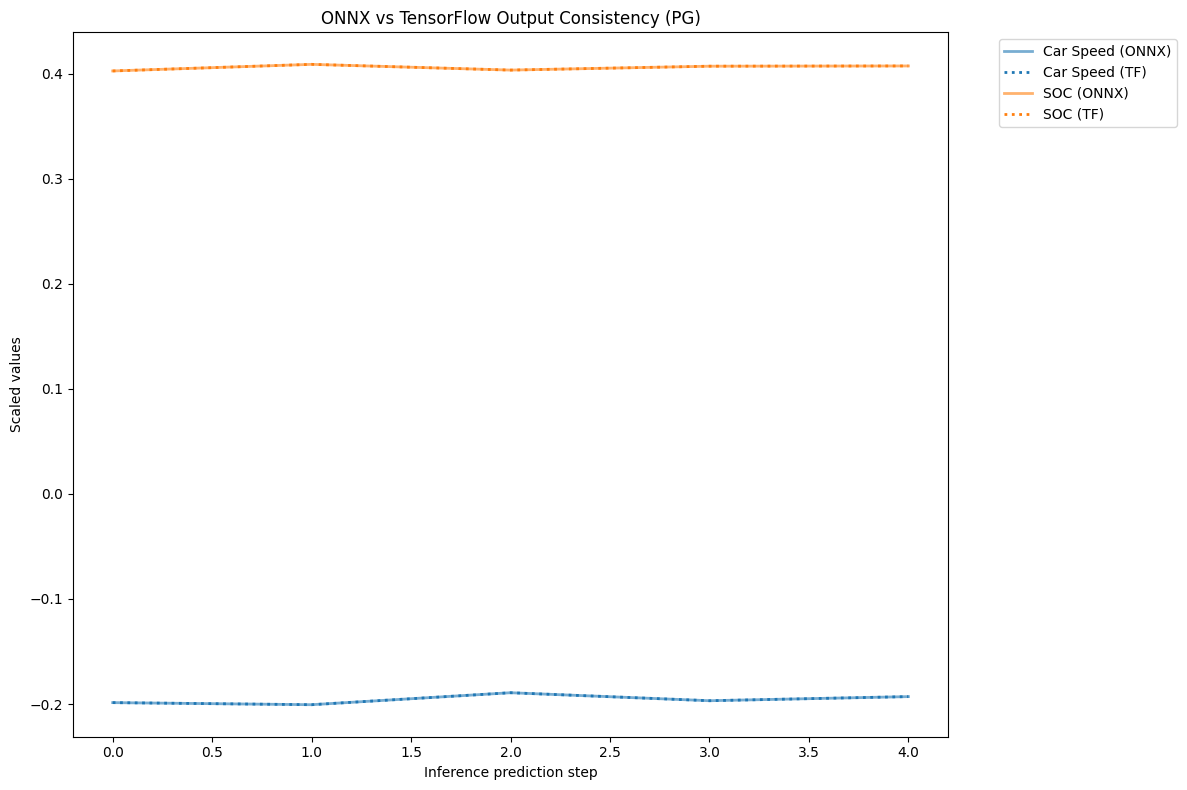

In [47]:
# Create DataFrame for comparison
onnx_results_pg = np.array(y_predict_scaled_list) # PG ONNX results
tf_results_pg = np.array(y_predict_scaled_pg_tf_list)

diff_pg = np.abs(onnx_results_pg - tf_results_pg)

# Calculate metrics
max_diff_pg = np.max(diff_pg, axis=0)
avg_diff_pg = np.mean(diff_pg, axis=0)
rmse_pg = np.sqrt(np.mean((onnx_results_pg - tf_results_pg)**2, axis=0))

overall_max_pg = np.max(diff_pg)
overall_mae_pg = np.mean(diff_pg)
overall_rmse_pg = np.sqrt(np.mean((onnx_results_pg - tf_results_pg)**2))

print(f"Overall Max Absolute Difference (PG): {overall_max_pg}")
print(f"Overall Mean Absolute Difference (PG - MAE): {overall_mae_pg}")
print(f"Overall Root Mean Squared Error (PG - RMSE): {overall_rmse_pg}")
print("-" * 30)

# Summary DataFrame
metrics_df_pg = pd.DataFrame({
    'Variable': labels,
    'Max Difference': max_diff_pg,
    'MAE': avg_diff_pg,
    'RMSE': rmse_pg
})
print("Per-variable metrics (PG Scaled):")
print(metrics_df_pg)

# Plotting Comparison
_, ax = plt.subplots(figsize=(12,8))

for var in range(plot_vars): # plot_vars is likely 2 here
    color = f'C{var}'
    ax.plot(onnx_results_pg[:, var], label=f'{labels[var]} (ONNX)', linestyle='-', color=color, alpha=0.6, linewidth=2)
    ax.plot(tf_results_pg[:, var], label=f'{labels[var]} (TF)', linestyle=':', color=color, alpha=1.0, linewidth=2)

ax.set_ylabel('Scaled values')
ax.set_xlabel('Inference prediction step')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('ONNX vs TensorFlow Output Consistency (PG)')
plt.tight_layout()
plt.show()

Per-variable metrics (PG Real Units):
    Variable  Max Difference           MAE          RMSE
0  Car Speed    9.894371e-06  4.935265e-06  5.843688e-06
1        SOC    5.960464e-08  4.768372e-08  5.331201e-08


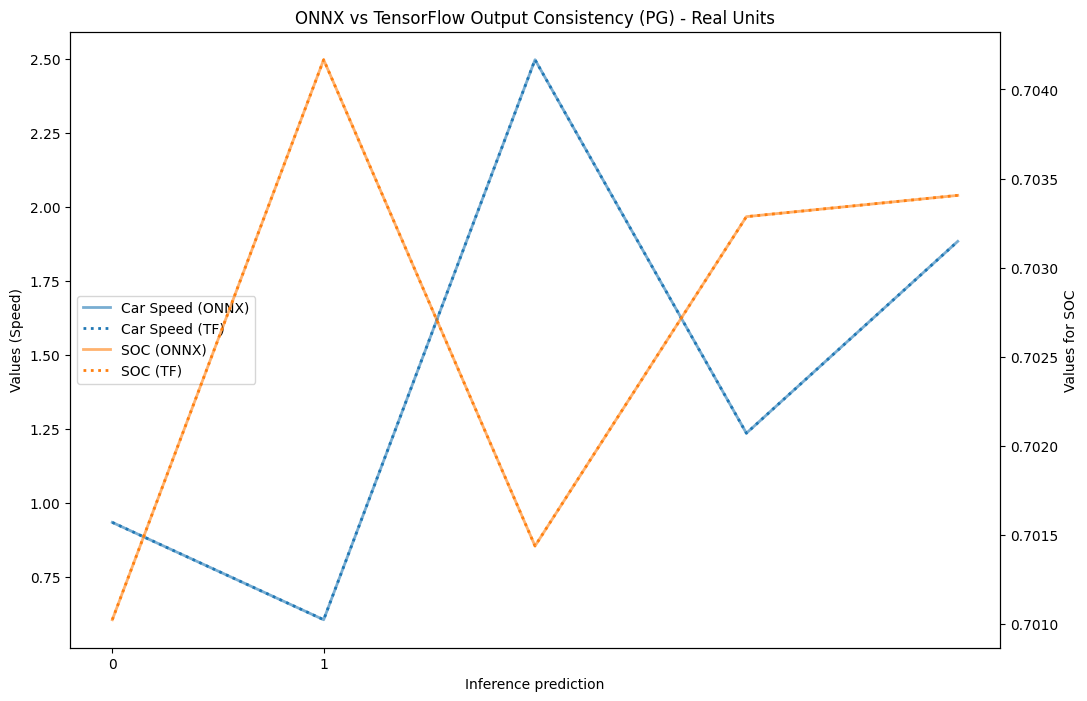

,Car Speed,SOC
0,0.934681,0.701024
1,0.605817,0.704167
2,2.497819,0.701438
3,1.236002,0.703286
4,1.884182,0.703406


In [48]:
y_pred_tf_list = []

for pred in range(len(y_predict_scaled_pg_tf_list)):
    y_pred = PGscaler_inv_out.transform(y_predict_scaled_pg_tf_list[pred].reshape(1, -1))
    y_pred_tf_list.append(y_pred[0][0])

tf_plot_data_real = np.array(y_pred_tf_list)
onnx_plot_data_real = plot_data # already computed in ONNX section

# Metrics Calculation for Real Units
diff_real = np.abs(onnx_plot_data_real - tf_plot_data_real)
max_diff_real = np.max(diff_real, axis=0)
mae_real = np.mean(diff_real, axis=0)
rmse_real = np.sqrt(np.mean((onnx_plot_data_real - tf_plot_data_real)**2, axis=0))

metrics_df_real = pd.DataFrame({
    'Variable': labels,
    'Max Difference': max_diff_real,
    'MAE': mae_real,
    'RMSE': rmse_real
})

print("Per-variable metrics (PG Real Units):")
print(metrics_df_real)


# Plot results
_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    color = f'C{var}'
    if var == 0:
        ax.plot(onnx_plot_data_real[:,var], label=f'{labels[var]} (ONNX)', linestyle='-', color=color, alpha=0.6, linewidth=2)
        ax.plot(tf_plot_data_real[:,var], label=f'{labels[var]} (TF)', linestyle=':', color=color, alpha=1.0, linewidth=2)
    else:
        ax2.plot(onnx_plot_data_real[:,var], label=f'{labels[var]} (ONNX)', linestyle='-', color=color, alpha=0.6, linewidth=2)
        ax2.plot(tf_plot_data_real[:,var], label=f'{labels[var]} (TF)', linestyle=':', color=color, alpha=1.0, linewidth=2)

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values (Speed)')
ax.set_xlabel('Inference prediction')

# Combine legends
lines, labels_l = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels_l + labels2, loc='center left')

ax2.set_ylabel('Values for SOC')

plt.title('ONNX vs TensorFlow Output Consistency (PG) - Real Units')
plt.show()

# Display DataFrame of TF real results
y_pred_tf_df = pd.DataFrame(data=tf_plot_data_real, columns=labels)
y_pred_tf_df